# Algorytmy macierzowe — lab 2

### Krzysztof Kopel, Marcin Szulc

## Cel laboratorium
Celem laboratorium było zaimplementowanie i przetestowanie algorytmów rekurencyjnego odwracania macierzy, rekurencyjnej eliminacji Gaussa oraz rekurencyjnej LU faktoryzacji wraz z liczeniem wyznacznika. Każdy pomiar wykonać mieliśmy raz z metodą Bineta, raz Strassena. Część testowa polegała głównie na określeniu zależności czasu wykonania, zużycia pamięci i liczby operacji zmiennoprzecinkowych od rozmiaru macierzy wejściowych.

## Ustalenia techniczne
Do implementacji algorytmów wykorzystaliśmy język Python w wersji 3.13. Macierze zostały zaimplementowane jako Numpy ndarrays, które dzięki swojej implementacji są szybsze od tradycyjnych Pythonowych list wielowymiarowych, jak również posiadają kilka przydatnych dla nas metod, np. do sprawdzania rozmiaru macierzy. Każdy algorytm "opakowaliśmy" w klasę, w której zapisywaliśmy informację na temat liczby wykonanych operacji zmiennoprzecinkowych oraz zużycia pamięci, a także odniesienie do właściwego algorytmu mnożenia macierzy (tzw. wrapper). Do pomiaru czasu wykonania posłużyła nam biblioteka time. Do wizualizacji wyników wykorzystaliśmy bibliotekę matplotlib.
#### Generowanie macierzy testowych
Wygenerowaliśmy macierze kwadratowe o rozmiarach od 1 x 1 do 1000 × 1000 (po dwie każdego rozmiaru), zawierające losowe liczby zmiennoprzecinkowe z przedziału $[0.00000001, 1]$.

In [1]:
import numpy as np

matrices = [np.random.uniform(0.00000001, 1, (i, i)) for i in range(1, 1000)]

In [2]:
import matplotlib.pyplot as plt

## Odwracanie macierzy
### Opis algorytmu

Ideą algorytmu odwracania macierzy $A$ jest przekształcenie układu równań (zapisanego macierzowo) $$AX = I$$ do postaci $$IX = A^{-1}$$

Naszą macierz rozdzielamy początkowo na 4 bloki, mamy zatem:
$$
\begin{array}{cc}
\begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix}
&
*
&
\begin{bmatrix}
X_{11} & X_{12}\\
X_{21} & X_{22}
\end{bmatrix}
&
=
&\begin{bmatrix}
I & 0\\
0 & I
\end{bmatrix}
\end{array}
$$
 Przkształceń będziemy dokonywać poprzez następujące operacje ($B = A^{-1}$):
1. $A_{11}^{-1} = inverse(A_{11})$ (rekurencyjnie)
2. $S_{22} = A_{22} - A_{21} * A_{11}^{-1} * A_{12}$
3. $S_{22}^{-1} = inverse(S_{22})$ (rekurencyjnie)
4. $B_{11} = A_{11}^{-1} * (I + A_{12}S_{22}^{-1}A_{21}A_{11}^{-1})$
5. $B_{12} = -A_{11}^{-1} * A_{12} * S_{22}^{-1}$
6. $B_{21} = -S_{22}^{-1} * A_{21} * A{11}^{-1}$
7. $B_{22} = S_{22}^{-1}$

Przekształcenia te są równoważne ze zmianami poszczególnych wierszy, w sposób dość podobny do znanego nam z eliminacji Gaussa (czyli np. przez pomnożenie jednego wiersza przez jakąś wielokrtoność innego).

### Fragmenty kodu

```python
def inverse(self, matrix: np.ndarray) -> np.ndarray:
    """
    Funkcja odwracająca macierz z wykorzystaniem sposobu podanego na wykładzie.
    :param matrix: Macierz do odwrócenia
    :return: Macierz odwrotna do podanej
    """
    if tuple(matrix.shape) == (1, 1):
        return np.array([[1 / matrix[0][0]]])

    a11, a12, a21, a22 = self.split(matrix)

    a11_rev = self.inverse(a11)

    s22 = a22 - self.matmul(a21, a11_rev, a12)

    s22_rev = self.inverse(s22)

    b11 = self.matmul(a11_rev, np.eye(a11_rev.shape[0], a11_rev.shape[1]) + self.matmul(a12, s22_rev, a21, a11_rev))

    b12 = -1 * self.matmul(a11_rev, a12, s22_rev)

    b21 = -1 * self.matmul(s22_rev, a21, a11_rev)

    return np.vstack((np.hstack((b11, b12)), np.hstack((b21, s22_rev))))
```

## Rozkład LU i wyznacznik
### Opis algorytmu
Algorytm rozkładu LU polega na rozłożeniu macierzy $A$ na macierze $L$ (trójkątną dolną) i $U$ (trójkątną górną), takie, że
$$L * U = A$$

Zrobimy to, zauważając, że
$$
\begin{array}{cccccc}
A = \begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix}
&
=
&
\begin{bmatrix}
I & 0\\
0 & I
\end{bmatrix}
&
\begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix}
&
=
&
LU
\end{array}
$$
Przekształcimy te dwie macierze tak, aby lewa (jednostkowa) stała się macierzą $L$, a prawa (dotychczasowa macierz $A$) stała się macierzą $U$.

Algorytm zapisany jako lista kroków wygląda tak:
1. $[L_{11}, U_{11}] = LU(A_{11})$
2. $U_{11}^{-1} = inverse(U_{11})$
3. $L_{21} = A_{21}U_{11}^{-1}$
4. $L_{11}^{-1} = inverse(L_{11})$
5. $U_{12} = L_{11}^{-1}A_{12}$
6. $S = A_{22} - A_{21}U_{11}^{-1}L_{11}^{-1}A_{12}$
7. $[L_s, U_s] = LU(S)$
8. $U_{22} = U_s$
9. $L_{22} = L_s$

Ponownie, przekształcenia te są podobne (koncepcyjnie) do tych, które wykonujemy w trakcie eliminacji Gaussa, ewentualnie są zawołaniami rekurencyjnymi lub wykorzystującymi inwersję, opisaną w poprzednim punkcie.

Wyznacznik macierzy liczymy, wykorzystując fakt, że wyznacznik iloczynu macierzy to iloczyn wyznaczników, a wyznacznik macierzy trójkątnej to iloczyn elementów na jej przekątnej.
$$det(A) = det(LU) = det(L) * det(U) = 1 * det(U)$$

**Ważna uwaga**: ze względu na to, że przy liczeniu wyznacznika większą część czasu zajmuje sama faktoryzacja LU, nie zdecydowaliśmy się na przeprowadzenie dokładnej analizy działania algorytmu dla wyznacznika i LU osobno, tylko po prostu przeanalizowaliśmy czas działania LU. Podobnie zrobiliśmy z analizą zużycia pamięci i FLOPSów.


### Fragmenty kodu

```python
def lu(self, matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Funkcja przeprowadzająca rozkład LU podanej macierzy.
    :param matrix: Macierz wejściowa.
    :return: Krotka macierzy L i U.
    """
    if matrix.shape[0] == 1 and matrix.shape[1] == 1:
        return np.ones_like(matrix), matrix

    a11, a12, a21, a22 = self.split(matrix)

    l11, u11 = self.lu(a11)

    u11_rev = self.inverse(u11)

    l21 = self.matmul(a21, u11_rev)

    l11_rev = self.inverse(l11)

    u12 = self.matmul(l11_rev, a12)

    l22 = a22 - self.matmul(a21, u11_rev, l11_rev, a12)

    ls, us = self.lu(l22)

    u22 = us
    l22 = ls

    lu_tuple = (np.vstack((np.hstack((l11, np.zeros((l11.shape[0], l22.shape[1])))), np.hstack((l21, l22)))),
            np.vstack((np.hstack((u11, u12)), np.hstack((np.zeros((u22.shape[0], u11.shape[1])), u22)))))
    return lu_tuple

def det(self, matrix: np.ndarray) -> float:
    """
    Funkcja obliczająca wyznacznik macierzy za pomocą rozkładu LU.
    :param matrix: Macierz wejściowa.
    :return: Wyznacznik macierzy.
    """
    _, u = self.lu(matrix)
    det = 1
    for num in [u[i][i] for i in range(u.shape[0])]:
        det *= num
    return det

def det_lu(self, u_matrix: np.ndarray) -> float:
    """
    Funkcja obliczająca wyznacznik macierzy trójkątnej górnej.
    :param u_matrix: Macierz trójkątna górna.
    :return: Wyznacznik macierzy.
    """
    det = 1
    for i, num in enumerate(u_matrix):
        det *= num[i]
    return det
```

## Blokowa Eliminacja Gaussa

Algorytm ten opiera się o kilka głównych kroków: 
- podzielenie macierzy na cztery blokowe części (w miare możliwości równe)

$$A = \begin{bmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{bmatrix}$$

- jeśli część jest wielkości 1x1: Zwróć część
- wykonaj LU faktoryzację lewej górnej części (dostajesz L11, U11)

$$A_{11} = L_{11} U_{11}$$

- części lewą górną i prawą górną przemnóż przez odwrotność L11

$$\begin{bmatrix} A'_{11} & A'_{12} \end{bmatrix} = L_{11}^{-1} \begin{bmatrix} A_{11} & A_{12} \end{bmatrix} = \begin{bmatrix} U_{11} & L_{11}^{-1} A_{12} \end{bmatrix}$$


- lewą dolną część zapisz, a w zwracanej macierzy wypełnij zerami
- dla prawej dolnej części oblicz S (dopełnienie Shura)

$$S = A_{22} - A_{21} A_{11}^{-1} A_{12}$$

- dla S wróć do początku i oblicz jego eliminację Gaussa

$$S' = Gauss(S)$$

- zwróć wynikową macierz postaci: 
    - lewa górna część i prawa górna część przemnożone przez odwrotność L
    - lewa dolna część wypełniona zerami, prawa dolna część obliczona eliminacja Gaussa z S

$$A_{\text{final}} = \begin{bmatrix} U_{11} & A'_{12} \\ 0 & S' \end{bmatrix}
$$


### Fragmenty kodu

```python
def gaussElimination(self, matrix: np.ndarray, topCall: bool = True) -> np.ndarray:
    """
    Rekurencyjna blokowa eliminacja Gaussa: dzieli macierz na bloki,
    wykonuje eliminację na bloku A11, oblicza dopełnienie Schura
    i rekurencyjnie przetwarza blok dolny prawy. Zwraca
    macierz po jednym pełnym kroku eliminacji blokowej.
    """
    A = matrix[:, :-1]
    b = matrix[:, -1]

    if A.shape == (1,1):
        return matrix

    A11, A12, A21, A22 = self.split(A)
    n1 = A11.shape[0]

    b1 = b[:n1].reshape(-1, 1)
    b2 = b[n1:].reshape(-1, 1)

    L11, U11 = self.LU(A11)
    L11_inv = self.inverse(L11)
    U11_inv = self.inverse(U11)

    A11p = U11
    A12p = self.matmul(L11_inv, A12)
    A21p = np.zeros_like(A21)

    S = A22 - self.matmul(A21, U11_inv, A12p)

    b1p = self.matmul(L11_inv, b1)

    b2p = b2 - self.matmul(A21, U11_inv, b1p)

    bottom = self.gaussElimination(np.column_stack((S, b2p)), topCall=False)

    A22p = bottom[:, :-1]
    b2pp = bottom[:, -1].reshape(-1, 1)

    A_top = np.hstack((A11p, A12p))
    A_bottom = np.hstack((A21p, A22p))
    A_new = np.vstack((A_top, A_bottom))

    b_new = np.concatenate((b1p, b2pp))


    return np.column_stack((A_new, b_new))
```

## Analiza algorytmu odwracania macierzy

**Ważne uwagi:**
1. Mówiąc o *rozmiarze macierzy*, mamy na myśli liczbę elementów w jednym wierszu/jednej kolumnie, a nie liczbę wszystkich elementów macierzy.
2. Algorytm odpaliliśmy dla każdego rozmiaru macierzy kilka razy, po czym wzięliśmy medianę czasu wykonania, aby zminimalizować wpływ czynników zewnętrznych na pomiar czasu.
3. Analizę prowadziliśmy do rozmiaru, dla którego czas wykonania przekroczył 3 sekundy (wybraliśmy tę wartość metodą prób i błędów, szukając dobrego połączenia między sensownym czasem wykonania całości a chęcią oddania dobrze charakterystyki każdego z algorytmów).

In [5]:
from inverse import InverseWrapper
from binet import BinetWrapper
from strassen import StrassenWrapper
from time import perf_counter
from statistics import median


def measure_inverse(matrices, MultWrapperClass):

    mult_wrappers = [MultWrapperClass() for _ in range(len(matrices))]
    wrappers = [InverseWrapper(mult) for mult in mult_wrappers]

    for _ in range(3):
        for i, matrix in enumerate(matrices):

            t1 = perf_counter()
            wrappers[i].inverse(matrix)
            t2 = perf_counter()

            wrappers[i].time_used.append(t2 - t1)

            if wrappers[i].time_used[-1] > 3:
                break

    for wrapper in wrappers:
        if not wrapper.time_used:
            break

        wrapper.flops //= len(wrapper.time_used)
        wrapper.memory_used //= len(wrapper.time_used)
        wrapper.time_used = median(wrapper.time_used)

    return [
        w for w in wrappers
        if isinstance(w.time_used, float)
    ]


measurements_inverse_binet_wrappers = measure_inverse(
    matrices,
    BinetWrapper
)

measurements_inverse_strassen_wrappers = measure_inverse(
    matrices,
    StrassenWrapper
)

### Czas wykonania

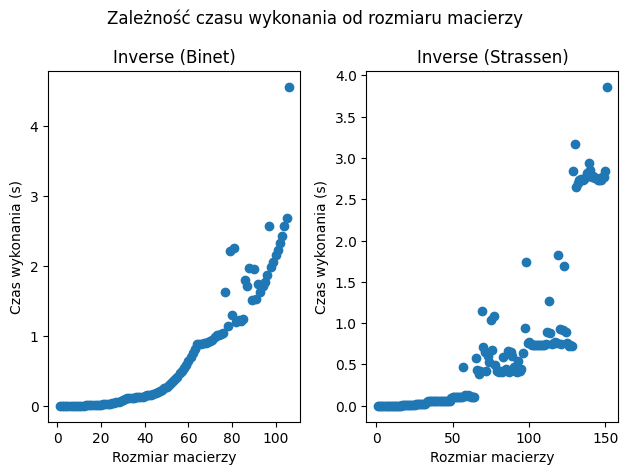

In [17]:
fig, ax = plt.subplots(1, 2)

fig.suptitle("Zależność czasu wykonania od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_inverse_binet_wrappers) + 1), [wrapper.time_used for wrapper in measurements_inverse_binet_wrappers])
ax[0].set_title("Inverse (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Czas wykonania (s)")

ax[1].scatter(range(1, len(measurements_inverse_strassen_wrappers) + 1), [wrapper.time_used for wrapper in measurements_inverse_strassen_wrappers])
ax[1].set_title("Inverse (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Czas wykonania (s)")
fig.tight_layout()
plt.show()

Czas odwracania macierzy przy wykorzystaniu algorytmu Strassena jest zauważalnie krótszy niż w przypadku algorytmu Bineta, co jest zgodne z oczekiwaniami, biorąc pod uwagę niższą złożoność czasową mnożenia macierzy Strassena w porównaniu do Bineta. Warto zauważyć, że również przejawia się tutaj "schodkowa" złożoność algorytmu Strassena, aczkolwiek (pewnie ze względu na różne rozmiary macierzy w wywołaniach rekurencyjnych) nie jest ona tak wyraźna, jak w przypadku samego mnożenia macierzy.

Dziwna rzecz stała się w przypadku algorytmu Bineta, gdzie dla niektórych rozmiarów macierzy w okolicy 80 czas wykonania był nieco dłuższy. Prawdopodobnie jest to jakoś związane z samąrekurencją albo interpreterem Pythona, ale nie udało nam się znaleźć konkretnego powodu tego zjawiska.

### Liczba operacji zmiennoprzecinkowych

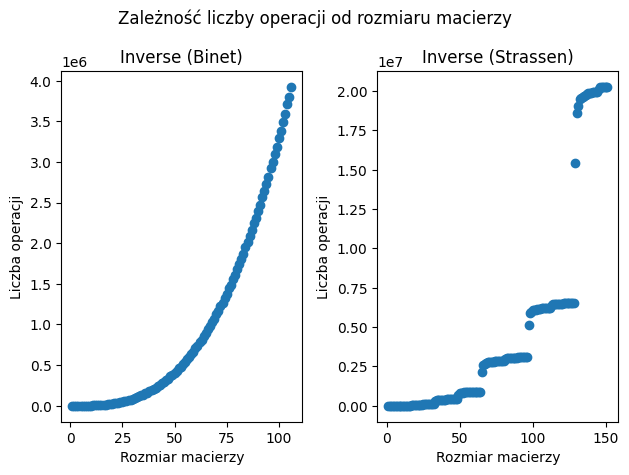

In [16]:
fig, axes = plt.subplots(1, 2)

axes[0].scatter(
    range(1, len(measurements_inverse_binet_wrappers) + 1),
    [w.flops for w in measurements_inverse_binet_wrappers]
)

fig.suptitle("Zależność liczby operacji od rozmiaru macierzy")

axes[0].set_title("Inverse (Binet)")
axes[0].set_xlabel("Rozmiar macierzy")
axes[0].set_ylabel("Liczba operacji")

axes[1].scatter(
    range(1, len(measurements_inverse_strassen_wrappers) + 1),
    [w.flops for w in measurements_inverse_strassen_wrappers]
)
axes[1].set_title("Inverse (Strassen)")
axes[1].set_xlabel("Rozmiar macierzy")
axes[1].set_ylabel("Liczba operacji")

fig.tight_layout()
plt.show()


### Zużycie pamięci

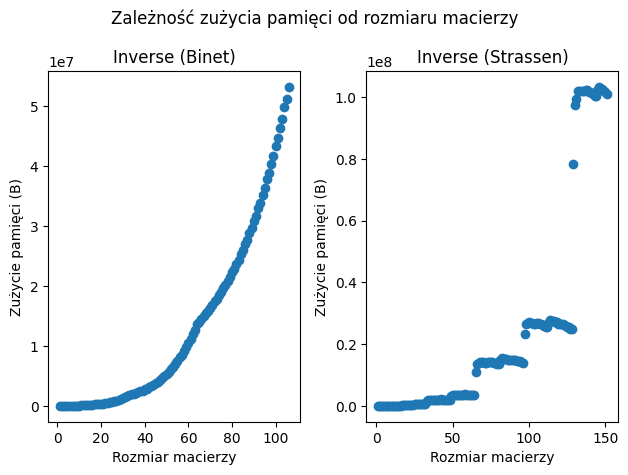

In [15]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność zużycia pamięci od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_inverse_binet_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_inverse_binet_wrappers])
ax[0].set_title("Inverse (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Zużycie pamięci (B)")

ax[1].scatter(range(1, len(measurements_inverse_strassen_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_inverse_strassen_wrappers])
ax[1].set_title("Inverse (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Zużycie pamięci (B)")
fig.tight_layout()
plt.show()

### Liczba operacji zmiennoprzecinkowych podzielona przez czas działania w sekundach

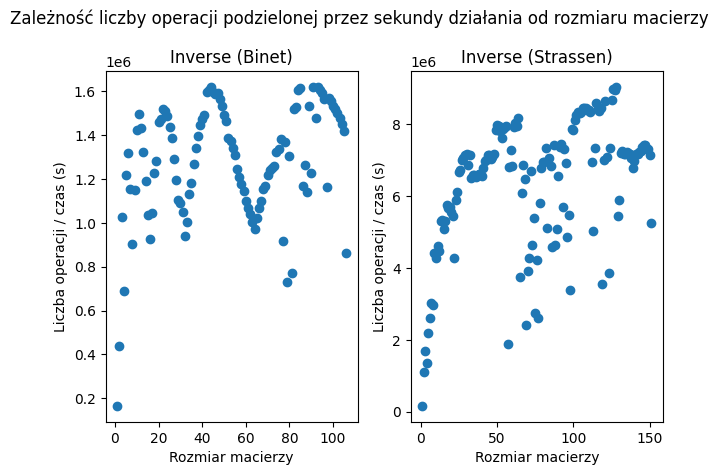

In [13]:
fig , ax = plt.subplots(1, 2)
fig.suptitle("Zależność liczby operacji podzielonej przez sekundy działania od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_inverse_binet_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_inverse_binet_wrappers])
ax[0].set_title("Inverse (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Liczba operacji / czas (s)")

ax[1].scatter(range(1, len(measurements_inverse_strassen_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_inverse_strassen_wrappers])
ax[1].set_title("Inverse (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Liczba operacji / czas (s)")
fig.tight_layout()
plt.show()

Wyniki ukazane na tych wykresach bardzo nas zdziwiły - pokazują one, że dla niektórych rozmiarów macierzy znacznie więcej czasu zajmują operacje inne niż te czysto matematyczne, np. przeniesienie danych w pamięci. Jednocześnie warto zauważyć (widać to zwłaszcza na wykresie dla algorytmu Bineta), że "dołki" znajdują się mniej więcej w rozmiarach odpowiadających macierzom $2^n x 2^n$, co pokazuje, że tam, gdzie rekurencja może dojść "w czystej postaci" do rozmiaru 1x1, algorytm wykonuje najmniej operacji typowo matematycznych, a więcej związanych z zarządzaniem pamięcią. Ma to sens - odpada nam wtedy mnożenie macierzy standardowym algorytmem $O(n^3)$ na koniec, czyli więcej czasu idzie na zarządzanie pamięcią.

Warto zwrócić uwagę również na to, że algorytm Strassena wykonuje znacznie więcej operacji na sekundę, co pokazuje, że jest on lepszy w wykorzystaniu zasobów, poświęcając większą część czasu na same obliczenia, a nie na manipulacje macierzami w pamięci.

## Analiza algorytmu faktoryzacji LU

In [14]:
from lu import LUWrapper

def measure_lu(matrices, MultWrapperClass):
    """
    matrices: lista macierzy
    MultWrapperClass: BinetWrapper lub StrassenWrapper
    """

    mult_wrappers = [MultWrapperClass() for _ in range(len(matrices))]

    wrappers = [LUWrapper(mult) for mult in mult_wrappers]

    for _ in range(3):
        for i, matrix_a in enumerate(matrices):

            t1 = perf_counter()
            wrappers[i].lu(matrix_a)
            t2 = perf_counter()

            wrappers[i].time_used.append(t2 - t1)

            if wrappers[i].time_used[-1] > 3:
                break

    for wrapper in wrappers:
        if not wrapper.time_used:
            break

        wrapper.flops //= len(wrapper.time_used)
        wrapper.memory_used //= len(wrapper.time_used)
        wrapper.time_used = median(wrapper.time_used)

    return [
        w for w in wrappers
        if isinstance(w.time_used, float)
    ]


measurements_lu_binet_wrappers = measure_lu(
    matrices,
    BinetWrapper
)

measurements_lu_strassen_wrappers = measure_lu(
    matrices,
    StrassenWrapper
)

### Czas wykonania

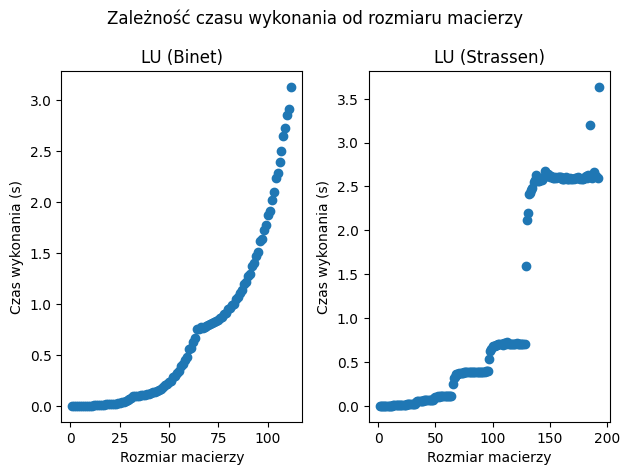

In [21]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność czasu wykonania od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.time_used for wrapper in measurements_lu_binet_wrappers])
ax[0].set_title("LU (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Czas wykonania (s)")
ax[1].scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.time_used for wrapper in measurements_lu_strassen_wrappers])
ax[1].set_title("LU (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Czas wykonania (s)")
fig.tight_layout()
plt.show()

Tutaj wykresy faktycznie przypominają to, co widzieliśmy na poprzednim laboratorium w odniesieniu do samych metod mnożenia macierzy.

### Liczba operacji zmiennoprzecinkowych

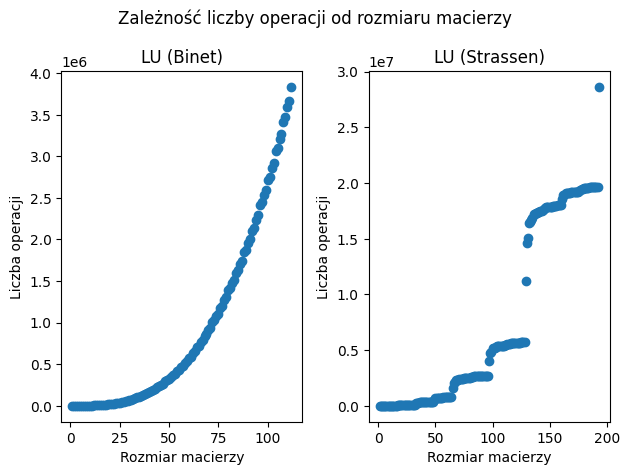

In [18]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność liczby operacji od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.flops for wrapper in measurements_lu_binet_wrappers])
ax[0].set_title("LU (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Liczba operacji")
ax[1].scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.flops for wrapper in measurements_lu_strassen_wrappers])
ax[1].set_title("LU (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Liczba operacji")
fig.tight_layout()
plt.show()

### Zużycie pamięci

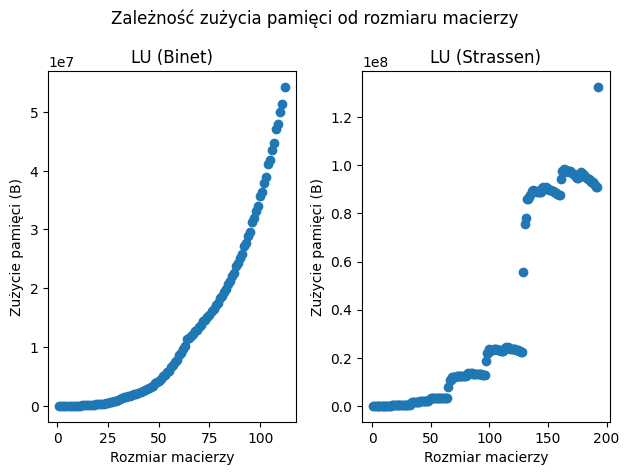

In [19]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność zużycia pamięci od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_lu_binet_wrappers])
ax[0].set_title("LU (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Zużycie pamięci (B)")
ax[1].scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_lu_strassen_wrappers])
ax[1].set_title("LU (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Zużycie pamięci (B)")
fig.tight_layout()
plt.show()

### Liczba operacji zmiennoprzecinkowych podzielona przez czas działania w sekundach

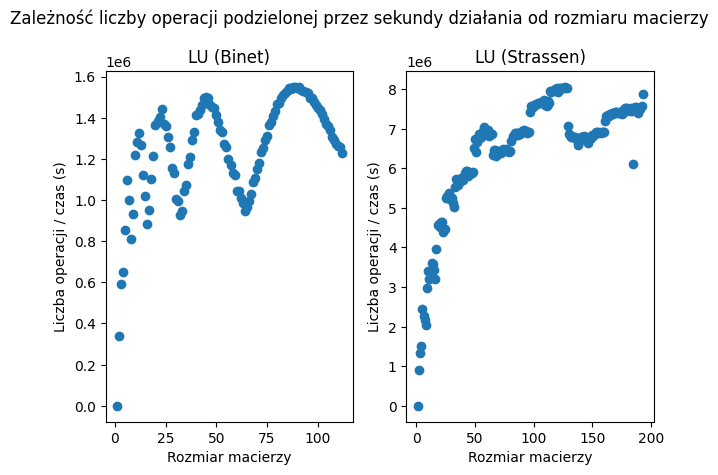

In [22]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność liczby operacji podzielonej przez sekundy działania od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_lu_binet_wrappers])
ax[0].set_title("LU (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Liczba operacji / czas (s)")
ax[1].scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_lu_strassen_wrappers])
ax[1].set_title("LU (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Liczba operacji / czas (s)")
fig.tight_layout()
plt.show()

Mamy tutaj sytuację podobną do tej w punkcie dotyczącym odwracania macierzy - wykresy są dość nieregularne, ale warto zauważyć, że ten dotyczący metody Strassena zdaje się być bardziej "monotoniczny". W przypadku Bineta widzimy zatem silną (choć nieoczywistą) zależność między liczbą operacji w jednostce czasu a rozmiarem macierzy wejściowej. Jest to ciekawa obserwacja, bo podobnych wykresów nie robiliśmy w poprzednim laboratorium.

## Analiza algorytmu blokowej eliminacji Gaussa

In [23]:
gauss_matrices = [np.random.uniform(0.00000001, 1, (i, i+1)) for i in range(1, 1000)]

In [24]:
from gauss_elimination import GaussWrapper
def measure_gauss(matrices, MultWrapperClass):
    """
    matrices: lista macierzy A
    MultWrapperClass: BinetWrapper lub StrassenWrapper
    """

    mult_wrappers = [MultWrapperClass() for _ in range(len(matrices))]

    wrappers = [GaussWrapper(mult) for mult in mult_wrappers]

    for _ in range(3):
        for i, matrix_a in enumerate(gauss_matrices):

            t1 = perf_counter()
            wrappers[i].gaussElimination(matrix_a)
            t2 = perf_counter()

            wrappers[i].time_used.append(t2 - t1)

            if wrappers[i].time_used[-1] > 4:
                break

    for wrapper in wrappers:
        if not wrapper.time_used:
            break

        wrapper.flops //= len(wrapper.time_used)
        wrapper.memory_used //= len(wrapper.time_used)
        wrapper.time_used = median(wrapper.time_used)

    return [
        w for w in wrappers
        if isinstance(w.time_used, float)
    ]


measurements_gauss_binet_wrappers = measure_gauss(
    matrices,
    BinetWrapper
)

measurements_gauss_strassen_wrappers = measure_gauss(
    matrices,
    StrassenWrapper
)

### Czas działania

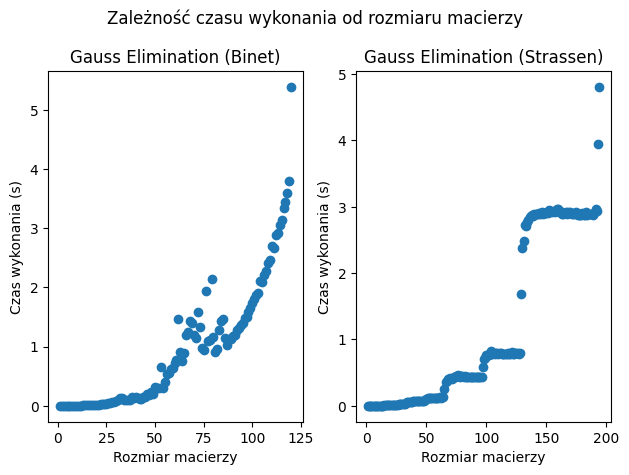

In [33]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność czasu wykonania od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.time_used for wrapper in measurements_gauss_binet_wrappers])
ax[0].set_title("Gauss Elimination (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Czas wykonania (s)")
ax[1].scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.time_used for wrapper in measurements_gauss_strassen_wrappers])
ax[1].set_title("Gauss Elimination (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Czas wykonania (s)")
fig.tight_layout()
plt.show()

Wystąpiła sytuacja podobna do tej w odwracaniu macierzy - algorytm Bineta dla pewnych rozmiarów zaczyna nieco odbiegać od oczekiwanego trendu wzrostu, aby potem do niego wrócić. Ciężko powiedzieć, czy jest to kwestia samego algorytmu, czy może interpretera Pythona, zarządzania pamięcią bądź komputera. Zakładamy jednak, że jest to efekt uboczny samej procedury liczenia, chociaż trochę nas to dziwi, bo braliśmy pod uwagę medianę z kilku pomiarów.

### Liczba operacji zmiennoprzecinkowych

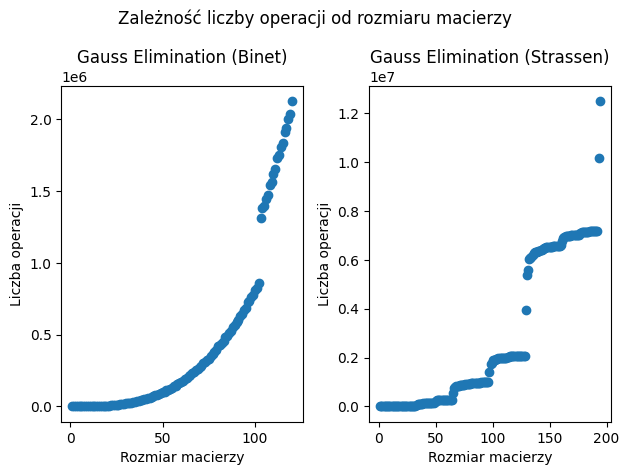

In [34]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność liczby operacji od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.flops for wrapper in measurements_gauss_binet_wrappers])
ax[0].set_title("Gauss Elimination (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Liczba operacji")
ax[1].scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.flops for wrapper in measurements_gauss_strassen_wrappers])
ax[1].set_title("Gauss Elimination (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Liczba operacji")
fig.tight_layout()
plt.show()

Algorytm Bineta zaczyna wykonywać dużo więcej operacji dla macierzy o rozmiarach powyżej około 100. Niestety, nie mamy za bardzo pomysłu, czemu takie zjawisko zachodzi.

### Zużycie pamięci

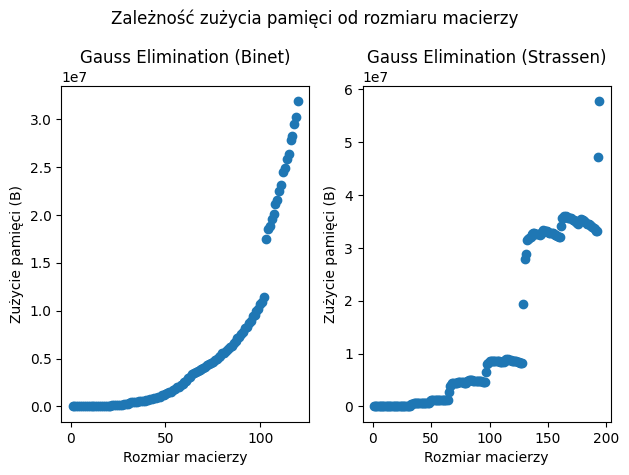

In [35]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność zużycia pamięci od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_gauss_binet_wrappers])
ax[0].set_title("Gauss Elimination (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Zużycie pamięci (B)")
ax[1].scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_gauss_strassen_wrappers])
ax[1].set_title("Gauss Elimination (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Zużycie pamięci (B)")
fig.tight_layout()
plt.show()

### Liczba operacji zmiennoprzecinkowych przez czas działania

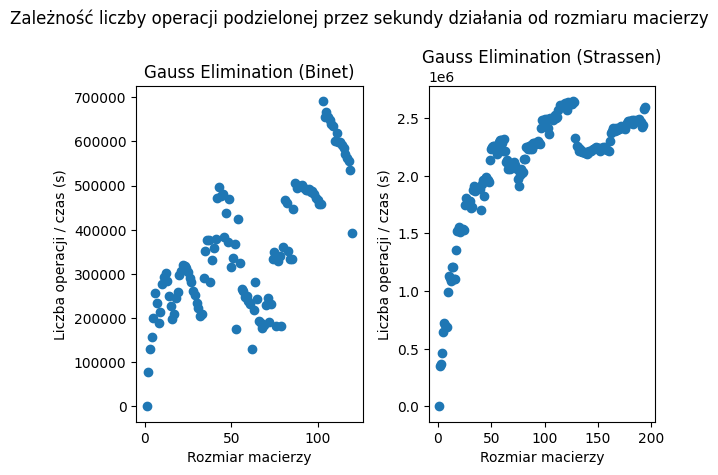

In [36]:
fig, ax = plt.subplots(1, 2)
fig.suptitle("Zależność liczby operacji podzielonej przez sekundy działania od rozmiaru macierzy")
ax[0].scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_gauss_binet_wrappers])
ax[0].set_title("Gauss Elimination (Binet)")
ax[0].set_xlabel("Rozmiar macierzy")
ax[0].set_ylabel("Liczba operacji / czas (s)")
ax[1].scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_gauss_strassen_wrappers])
ax[1].set_title("Gauss Elimination (Strassen)")
ax[1].set_xlabel("Rozmiar macierzy")
ax[1].set_ylabel("Liczba operacji / czas (s)")
fig.tight_layout()
plt.show()

Znowu mamy do czynienia z nieregularnym wzorcem, który opisywaliśmy w poprzednich punktach. Warto zauważyć, że algorytm Strassena wydaje się tutaj być bardziej stabilny i przewidywalny w działaniu niż Bineta.

## Podsumowanie
Wykonanie laboratorium pozwoliło nam zapoznać się z implementacjami popularnych algorytmów macierzowych (faktoryzacja LU, eliminacja Gaussa, szukanie odwrtoności macierzy) wykorzystującymi rekurencyjne mnożenie macierzy. Przekonaliśmy się, w jaki sposób wykorzystanie algorytmów Strassena bądź Bineta może wpływać na złożoność czasową i pamięciową bardziej złożonych procedur.

Jednocześnie pare wyników nas zaskoczyło (szczegóły w konkretnych punktach sprawozdania) i skłoniło do refleksji nad tym, jak wiele czynników może wpływać na efektywność algorytmów, zwłaszcza w kontekście zarządzania pamięcią i optymalizacji na poziomie sprzętowym.